In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

# Load and inspection of data
df = pd.read_csv("../data/USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
# Shape of Data Set
print(f"""
Shape of Data Set:
Rows = {df.shape[0]}
Columns = {df.shape[1]}
""")

# Data Types
df.info()

# Statistical Summary
df.describe()

# Missing Values
df.isnull().sum()

# Duplicate Rows
print(df.duplicated().sum())


Shape of Data Set:
Rows = 5000
Columns = 7

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
0


Observations:

• Dataset contains 5000 rows and 7 columns
• No missing values
• No duplicate rows
• Address is a text column

# Target variable analysis

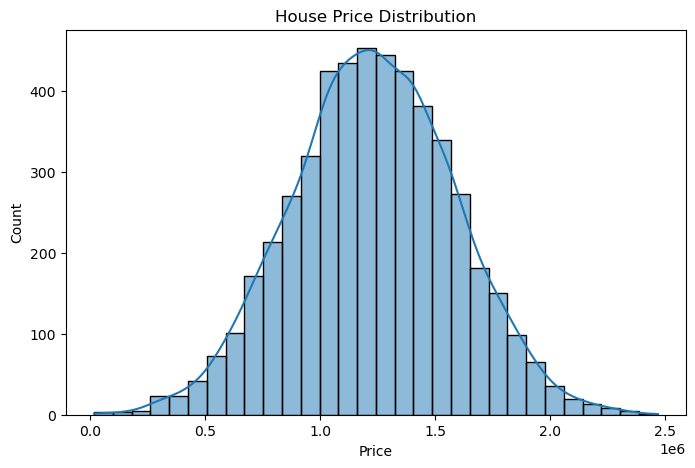

In [4]:

# Distribution of House Prices (Histogram)

plt.figure(figsize=(8,5))

sns.histplot(df['Price'], bins=30, kde=True)

plt.title("House Price Distribution")

plt.show()

In [5]:
# Statistical Summary
print(f"""
mean = {df['Price'].mean():.2f}
median = {df['Price'].median():.2f}
min = {df["Price"].min():.2f}
max = {df["Price"].max():.2f}
std = {df["Price"].std():.2f}
""")


mean = 1232072.65
median = 1232669.38
min = 15938.66
max = 2469065.59
std = 353117.63



# Feature distributions

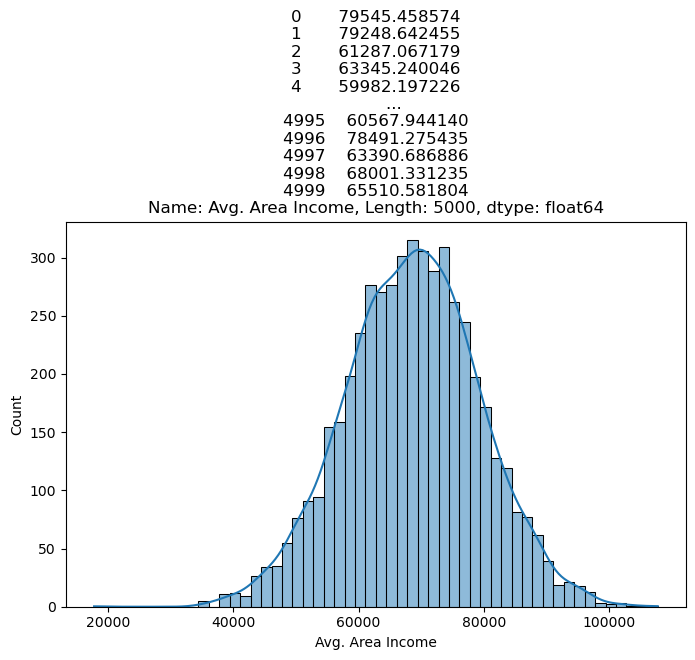

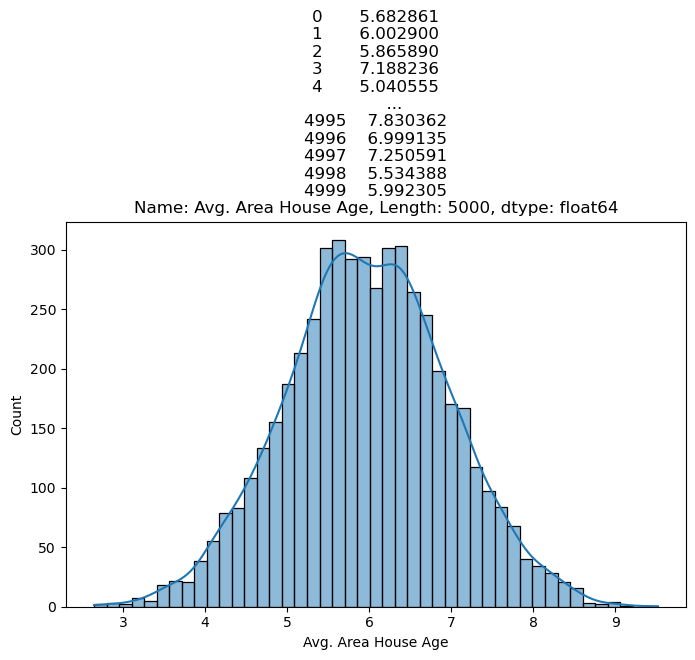

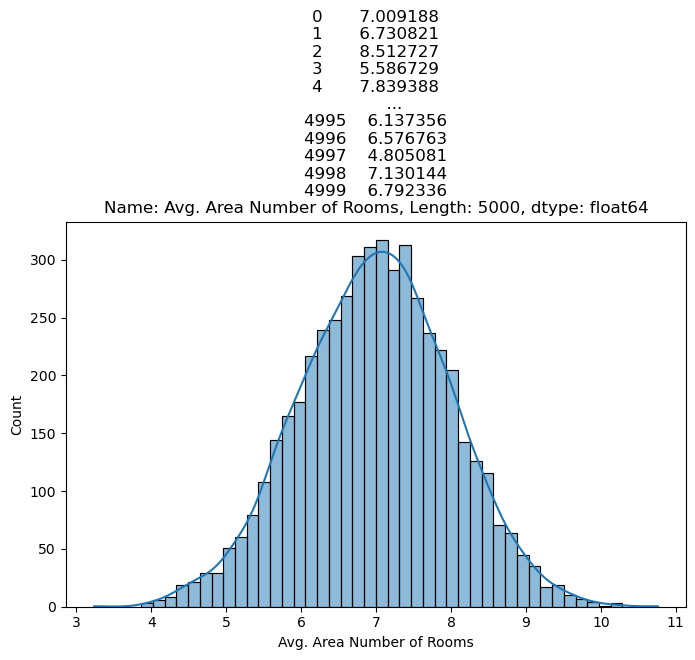

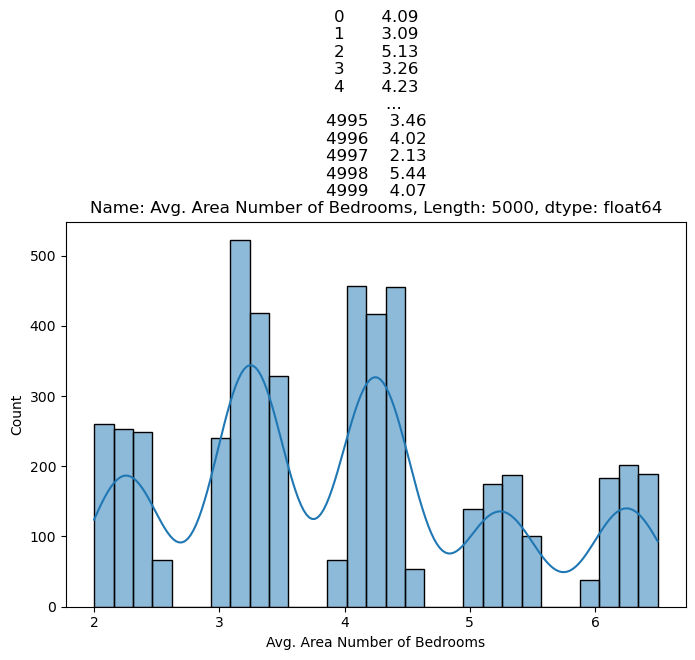

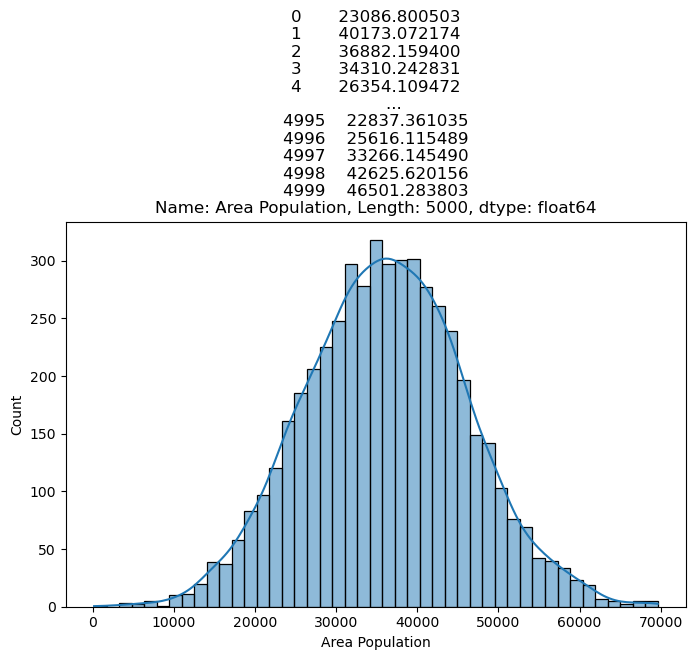

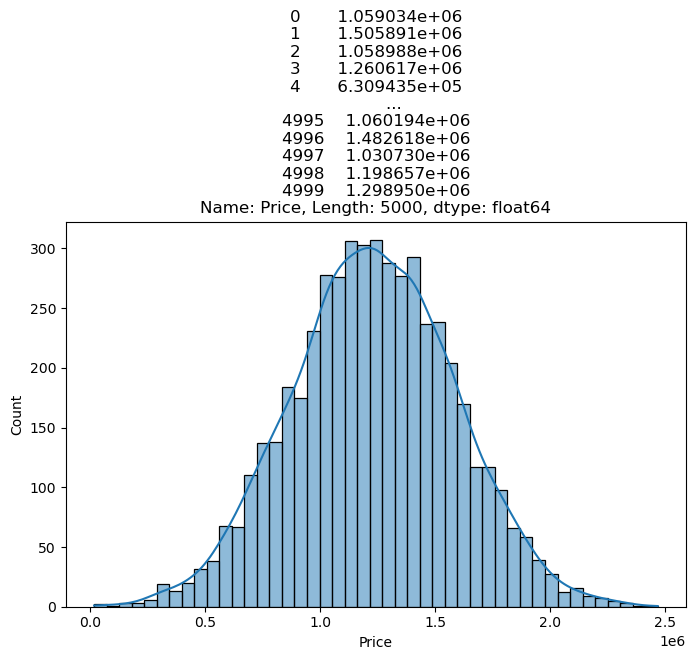

In [6]:
numerical_columns = df.select_dtypes(include='number').columns.to_list()
numerical_columns

for col in numerical_columns:
  plt.figure(figsize=(8,5))
  sns.histplot(df[col], kde=True)
  plt.title(df[col])
  plt.show()

# Correlation analysis

In [8]:
# Drop Address for correlation
corr_df = df.drop("Address", axis=1)
corr_matrix = corr_df.corr()
corr_matrix

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


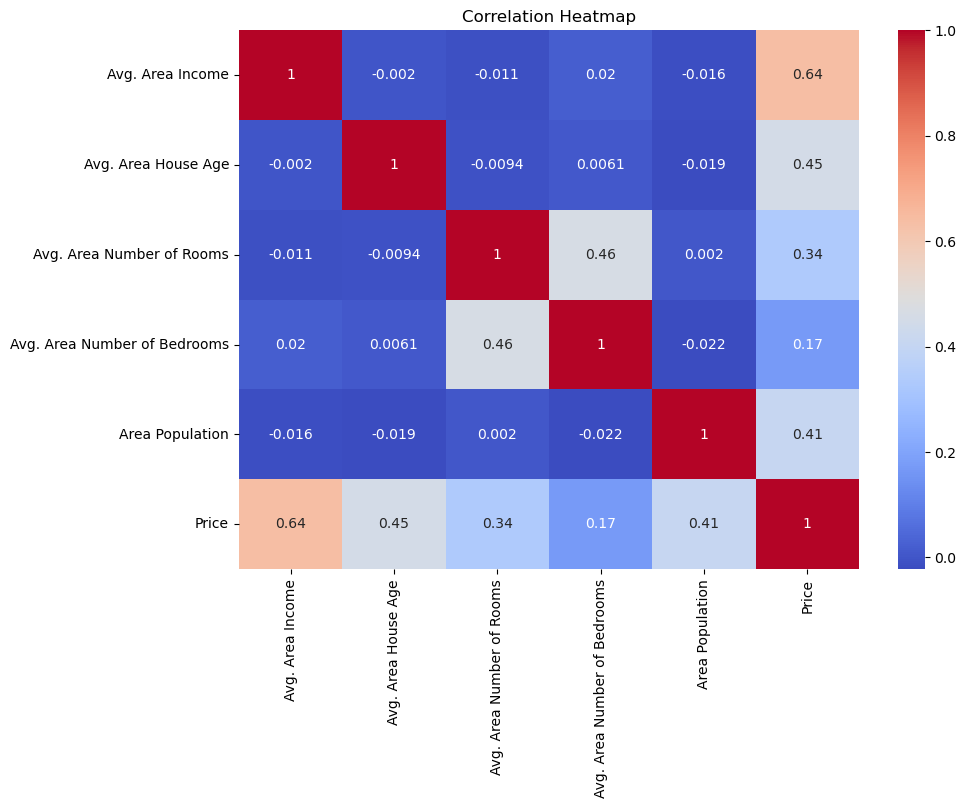

In [11]:
# Heatmap Analysis

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Avg. Area Income has the strongest correlation with Price

# Scatter plots

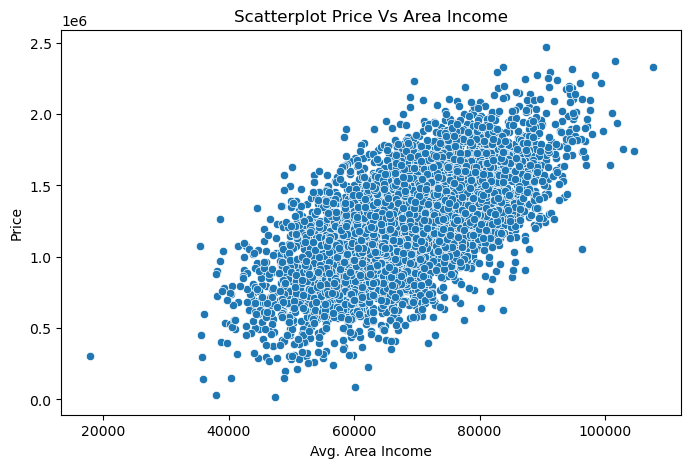

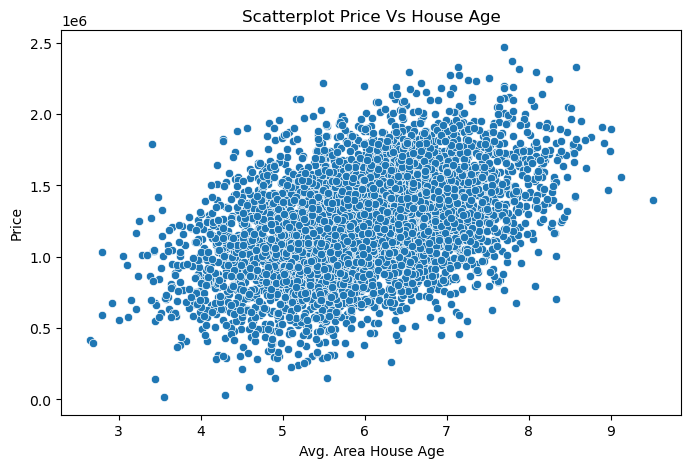

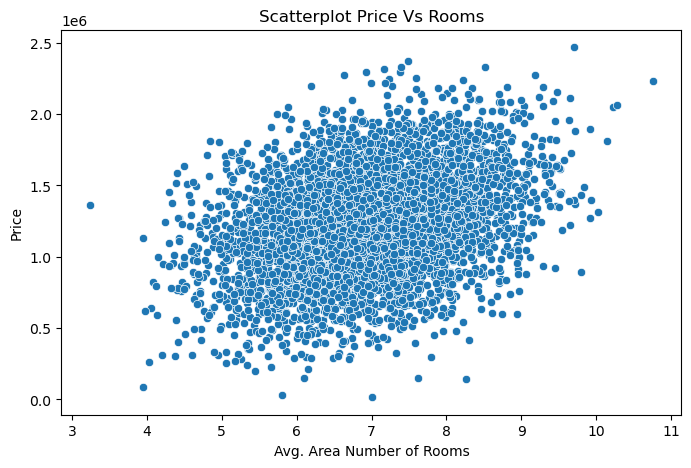

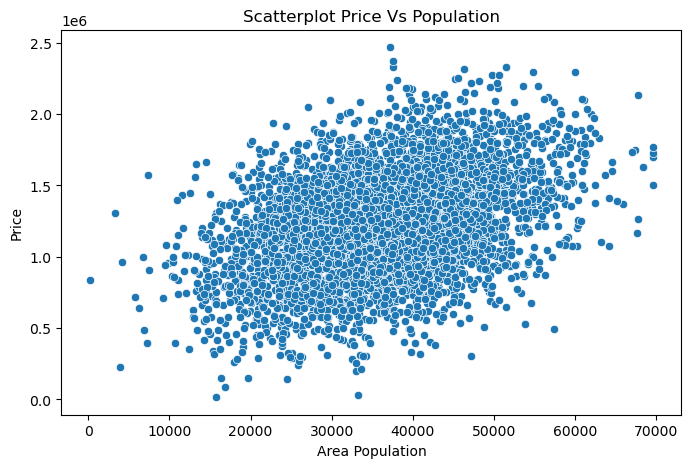

In [13]:
# Price Vs Area Income
plt.figure(figsize=(8,5))
sns.scatterplot(x="Avg. Area Income", y="Price", data=df)
plt.title("Scatterplot Price Vs Area Income")
plt.show()

# Price Vs House Age
plt.figure(figsize=(8,5))
sns.scatterplot(x="Avg. Area House Age", y="Price", data=df)
plt.title("Scatterplot Price Vs House Age")
plt.show()

# Price Vs Rooms
plt.figure(figsize=(8,5))
sns.scatterplot(x="Avg. Area Number of Rooms", y="Price", data=df)
plt.title("Scatterplot Price Vs Rooms")
plt.show()

# Price Vs Population
plt.figure(figsize=(8,5))
sns.scatterplot(x="Area Population", y="Price", data=df)
plt.title("Scatterplot Price Vs Population")
plt.show()

# Key Findings

### 1. Avg. Area Income has the strongest correlation with Price.

### 2. All major features show positive linear relationships.

### 3. Area Population has moderate influence.

### 4. Address is not useful for traditional regression.

### 5. Since relationships appear mostly linear, Linear Regression and Ridge Regression should perform well.